## Run_QLC_FT

This code solves the QLC problem in Fourier space. Parameters include:
- $\overline N$, and $N^*$ (atomistic-level characteristics of the ice QLL thicknesses)
- $\sigma_o$ (difference in equilibrium supersaturation between microsurfaces I and II)
- $h_{pr}$ (thickness of a prismatic facet monolayer)
- $D_{surf}$ (surface diffusion coefficient of the QLL)
- $\nu_{kin}$ (kinetic velocity -- the rate at which water vapor strikes the surface)
- $L$ (physical length of the facet surface)
- $nx_{crystal}$ (number of discrete points used to represent the surface)
- $L$ (crystal dimension)
- $\sigma_{I,corner}$ (imposed supersaturation at the facet corner)
- $c_r$ (relative reduction in supersaturation at facet centers relative to corners, in fraction and %)
- $\tau_{eq}$ (time constant for ice/QLL freezing/thawing)

In [2]:
from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
import numpy as np
from copy import copy as cp
import matplotlib.pylab as plt
from scipy.integrate import solve_ivp
from matplotlib import rcParams
from time import time
from scipy.fft import fftfreq, rfftfreq
from scipy.fft import rfft, irfft
# from scipy.fft import dct as rfft
# from scipy.fft import idct as irfft

import sys
import QLCstuff as QLC
import f90nml

In [3]:
%matplotlib inline
ticklabelsize = 15
linewidth = 1
fontsize = 15
titlefontsize = 8
markersize = 10

### Getting parameters for this run

In [5]:
inputfile = "GI parameters - Reference limit cycle (for testing).nml"
inputfile = "GI parameters - Reference limit cycle.nml"
inputfile = "GI parameters.nml"
inputfile = "GI parameters - Table 1.nml"

# For readability ...
print('Using parameter file '+inputfile+' ...')

print('\nFrom the GrowthInstability (GI) namelist:')
GI=f90nml.read(inputfile)['GI'] # Read the main parameter namelist

# Supersaturation at the corner of a facet
sigmaI_corner = GI['sigmaI_corner']
sigmaI_corner_units = GI['sigmaI_corner_units']
sigmaI_corner = AssignQuantity(sigmaI_corner,sigmaI_corner_units)
print('sigmaI_corner =', sigmaI_corner)

# Difference in equilibrium supersaturation between microsurfaces I and II
sigma0 = GI['sigma0']
sigma0_units = GI['sigma0_units']
sigma0 = AssignQuantity(sigma0,sigma0_units)
print('sigma0 =',sigma0)

# Reduction of supersaturation at the facet cental
c_r = GI['c_r']
c_r_units = GI['c_r_units']
c_r = AssignQuantity(c_r,c_r_units)
print('c_r =',c_r)

# Properties of the QLL
Nbar = GI['Nbar']; print('Nbar', Nbar)
Nstar = GI['Nstar']; print('Nstar', Nstar)

# Thickness of monolayers
h_pr = GI['h_pr']
h_pr_units = GI['h_pr_units']
h_pr = AssignQuantity(h_pr,h_pr_units) 
print('h_pr =', h_pr)

# Diffusion coeficient
D = GI['D']
D_units = GI['D_units']
D = AssignQuantity(D,D_units)
print('D =', D)

# Deposition velocity
nu_kin = GI['nu_kin']
nu_kin_units = GI['nu_kin_units']
nu_kin = AssignQuantity(nu_kin,nu_kin_units)
print('nu_kin =', nu_kin)

# Size of the facet
L = GI['L']
L_units = GI['L_units']
L = AssignQuantity(L,L_units)
print('L =', L)

# Crystal size -- needs to be an even number
nx_crystal = GI['nx_crystal']
print('nx (crystal) =', nx_crystal)

# Time constant for freezing/thawing
# tau_eq = GI['tau_eq']
# tau_eq_units = GI['tau_eq_units']
# tau_eq = AssignQuantity(tau_eq,tau_eq_units)
# print('tau_eq =',tau_eq)
t_eq = GI['t_eq']
t_eq_units = GI['t_eq_units']
t_eq = AssignQuantity(t_eq,t_eq_units)
print('t_eq =',t_eq)

# Integration algorithm (possibilities: RK45, BDF, RK23, DOP853, LSODA, and Radau)
odemethod = GI['odemethod']
print('odemethod =',odemethod)

Using parameter file GI parameters - Table 1.nml ...

From the GrowthInstability (GI) namelist:
sigmaI_corner = 22 percent
sigma0 = 20 percent
c_r = 0.2 percent
Nbar 1
Nstar 0.1
h_pr = 0.37 nanometer
D = 0.0002 micrometer ** 2 / microsecond
nu_kin = 0.264 / microsecond
L = 30 micrometer
nx (crystal) = 301
t_eq = 2 microsecond
odemethod = LSODA


In [6]:
# tau_eq is the same as t_eq
tau_eq = t_eq

In [17]:
# Conversions (in case inputs are in other units)
sigma0.ito('dimensionless')
h_pr.ito('micrometer')
D.ito('micrometer^2/microsecond')
nu_kin.ito('1/microsecond')
L.ito('micrometer')
sigmaI_corner.ito('dimensionless')
c_r.ito('dimensionless')
tau_eq.ito('microsecond')

### Variables that depend on the above

In [20]:
x_QLC = np.linspace(-L,L,nx_crystal)
deltax = x_QLC[1]-x_QLC[0]
print('Spacing of points on the ice surface =', deltax)

sigmaI_QLC = sigmaI_corner*(c_r*(x_QLC/L)**2+1-c_r)

print('nu_kin =',nu_kin)
# nu_kin_mlyperus = nu_kin/h_pr
# nu_kin_mlyperus.ito('1/microsecond'); print('nu_kin_mlyperus =', nu_kin_mlyperus)

omega_kin = nu_kin * t_eq; 
omega_kin.ito('dimensionless'); print('omega_kin =', omega_kin)

Doverdeltax2 = D/deltax**2


Spacing of points on the ice surface = 0.1999999999999993 micrometer
nu_kin = 0.264 / microsecond
omega_kin = 0.528 dimensionless


### Hertz-Knudsen checks

In [23]:
# Constants
R = AssignQuantity(8.314462618,'J /mol / kelvin')
M_H2O = AssignQuantity(18.015,'g/mol')
rho_ice = AssignQuantity(0.917,'g/cm^3')

def vapor_pressure_ice(T):

    T_tp = 273.16             # K, triple-point temperature
    P_tp = 611.657            # Pa, triple-point pressure
    DeltaH_sub = 51.0e3       # J mol^-1, enthalpy of sublimation
    R = 8.314

    """
    Equilibrium vapor pressure of water over ice
    using the integrated Clausius-Clapeyron equation
    referenced to the triple point.

    Parameters
    ----------
    T : float or array_like
        Temperature in K

    Returns
    -------
    P : float or ndarray
        Equilibrium vapor pressure in Pa
    """
    T = np.asarray(T)

    return P_tp * np.exp(
        -DeltaH_sub / R * (1.0 / T - 1.0 / T_tp)
    )

T_array = np.array([230, 240, 250, 260, 270, 273.16])
P_vap_eq_array = vapor_pressure_ice(T_array)

P_vap_eq_array = AssignQuantity(P_vap_eq_array,'pascal')
print('Temperatures')
T_array = AssignQuantity(T_array,'kelvin')
print(T_array)

print('Pressures')
print(P_vap_eq_array)

denom = 2*np.pi*R*T_array
gamma_pr = rho_ice * h_pr
nu_kin_Hertz_Knudsen_array = P_vap_eq_array * np.sqrt(M_H2O/denom) / gamma_pr
nu_kin_Hertz_Knudsen_array.ito('1/microsecond')
print('nu_kin')
nu_kin_Hertz_Knudsen_array_orig = nu_kin_Hertz_Knudsen_array*h_pr
nu_kin_Hertz_Knudsen_array_orig.ito('micrometer/second')
print(nu_kin_Hertz_Knudsen_array_orig)

omega_kin_array = t_eq*nu_kin_Hertz_Knudsen_array
omega_kin_array.ito('dimensionless') 

iselect = 2
print('at a temperature of', T_array[iselect], '...')
print('   Pvap =', P_vap_eq_array[iselect])
print('   nu_kin_orig =', nu_kin_Hertz_Knudsen_array_orig[iselect])
print('   nu_kin =', nu_kin_Hertz_Knudsen_array[iselect])
print('   omega_kin =', omega_kin_array[iselect])

Temperatures
[230.0 240.0 250.0 260.0 270.0 273.16] kelvin
Pressures
[9.044448023813436 27.47907755251116 76.38579897825234 196.27656527054674 470.28874216116304 611.657] pascal
nu_kin
[12.076995936276221 35.92008037368849 97.83255418792463 246.5031914048114 579.5934534516127 749.4456947988126] micrometer / second
at a temperature of 250.0 kelvin ...
   Pvap = 76.38579897825234 pascal
   nu_kin_orig = 97.83255418792463 micrometer / second
   nu_kin = 0.2644123086160125 / microsecond
   omega_kin = 0.528824617232025 dimensionless


### Runtime parameters from the namelist 

In [26]:
RT=f90nml.read(inputfile)['RT'] # Read the main parameter namelist

# How long
runtime = RT['runtime']
runtime_units = RT['runtime_units']
runtime = AssignQuantity(runtime,runtime_units)
print('runtime =', runtime)
runtime.ito('microsecond')

# Number of time steps to keep for reporting later
ntimes = RT['ntimes']

# Flag if we want more output
verbose = RT['verbose']

# Specify the time interval and initial conditions
tkeep_1Darr = np.linspace(0,runtime,ntimes)
Ntot_init_1D = np.ones(nx_crystal)
NQLL_init_1D = QLC.getNQLL(Ntot_init_1D,Nstar,Nbar)

print('This is a run from time', tkeep_1Darr[0].to('msec'),'to', tkeep_1Darr[-1].to('msec'))
print('dt =', tkeep_1Darr[1]-tkeep_1Darr[0])

runtime = 300 millisecond
This is a run from time 0.0 millisecond to 300.0 millisecond
dt = 6122.448979591837 microsecond


### Run the scenario in Cartesian space

In [29]:
Ntotkeep_1D, NQLLkeep_1D = QLC.run_f1d(\
           NQLL_init_1D,Ntot_init_1D,tkeep_1Darr,\
           Nbar, Nstar, sigma0, nu_kin, Doverdeltax2, tau_eq, sigmaI_QLC,\
           AssignQuantity,\
           verbose=0, odemethod=odemethod)
Nicekeep_1D = Ntotkeep_1D-NQLLkeep_1D

# Reporting and graphing
# Label for graphs
title_params = \
        "{:.0f}".format(L.magnitude)+' '+str(L.units)+\
        ", "+np.format_float_scientific(D.magnitude,precision=2)+" "+str(D.units)+\
        "\n"+\
        "{:.0f}".format(nu_kin.magnitude)+' '+str(nu_kin.units)+\
        "\n"+\
        "{:.3f}".format(sigmaI_corner.magnitude)+' '+str(sigmaI_corner.units)+\
        ", "+"{:.1f}".format(tau_eq.magnitude)+' '+str(tau_eq.units)+\
        ", "+"{:.3f}".format(c_r.to('percent').magnitude)+'%'+\
        ", "+odemethod+\
        "\n"

10 % elapsed time is 0.214 minutes
20 % elapsed time is 0.398 minutes
30 % elapsed time is 0.582 minutes
40 % elapsed time is 0.767 minutes
50 % elapsed time is 0.952 minutes
60 % elapsed time is 1.137 minutes
70 % elapsed time is 1.324 minutes
80 % elapsed time is 1.510 minutes
90 % elapsed time is 1.696 minutes
100% done
status =  0
message =  The solver successfully reached the end of the integration interval.
['message', 'nfev', 'njev', 'nlu', 'sol', 'status', 'success', 't', 't_events', 'y', 'y_events']


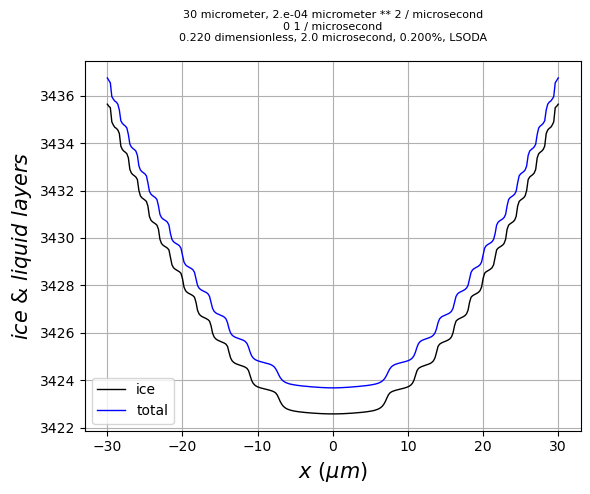

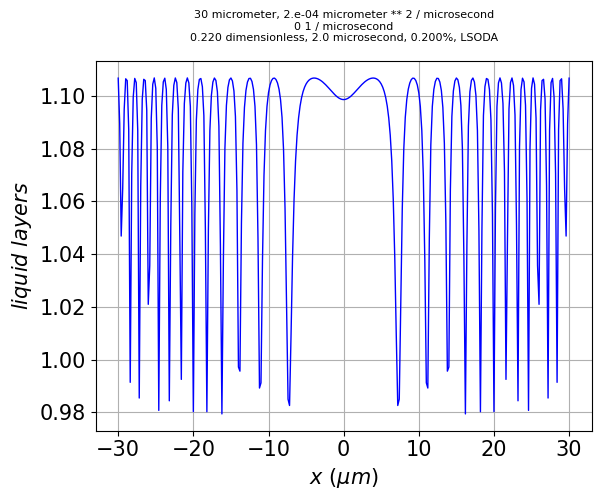

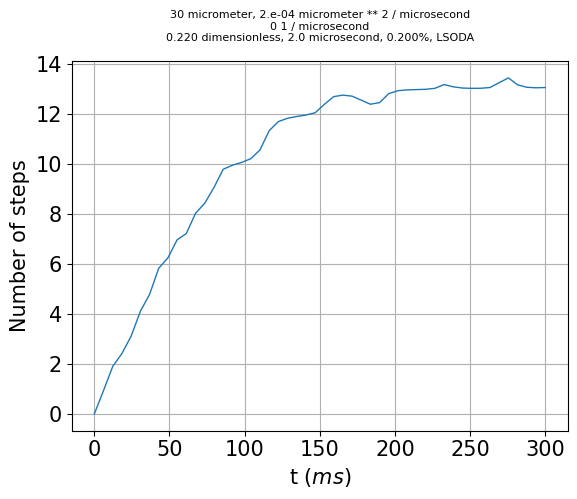

In [31]:
g_ice_QLC = QLC.report_1d_growth_results(\
        x_QLC,tkeep_1Darr,NQLLkeep_1D,Ntotkeep_1D,Nicekeep_1D,h_pr, \
        graphics=True,title_params=title_params)

### Run the scenario in FT space for comparison

In [ ]:
# DoverL2pi2 = D/L**2*np.pi**2
# Ntotkeep_1D_FT, NQLLkeep_1D_FT = QLC.run_f1d_FT(\
#            NQLL_init_1D,Ntot_init_1D,tkeep_1Darr,\
#            Nbar, Nstar, sigma0, nu_kin_mlyperus, DoverL2pi2, tau_eq, sigmaI_QLC,\
#            AssignQuantity,\
#            verbose=0, odemethod='RK45')
# Nicekeep_1D_FT = Ntotkeep_1D_FT-NQLLkeep_1D_FT

In [ ]:
# # Reporting
# g_ice_QLC = QLC.report_1d_growth_results(\
#         x_QLC,tkeep_1Darr,NQLLkeep_1D,Ntotkeep_1D,Nicekeep_1D,h_pr, \
#         graphics=True,title_params=title_params)

# g_ice_QLC = QLC.report_1d_growth_results(\
#         x_QLC,tkeep_1Darr,NQLLkeep_1D_FT,Ntotkeep_1D_FT,Nicekeep_1D_FT,h_pr, \
#         graphics=True,title_params=title_params)

# plt.figure()
# plt.plot(x_QLC.magnitude,Ntotkeep_1D[-1],label='Cartesian Ntot')
# plt.plot(x_QLC.magnitude,Ntotkeep_1D_FT[-1],'+',label='FT-derived Ntot')
# plt.xlabel('x (micrometers)')
# plt.grid(True)
# plt.legend()

# Ntot_difference_orig = Ntotkeep_1D[-1]-np.flip(Ntotkeep_1D[-1])
# Ntot_difference_FT = Ntotkeep_1D_FT[-1]-np.flip(Ntotkeep_1D_FT[-1])
# plt.figure()
# plt.plot(x_QLC.magnitude,Ntot_difference_orig,label='Cartesian Ntot')
# plt.plot(x_QLC.magnitude,Ntot_difference_FT,label='FT-derived Ntot')
# plt.xlabel('x (micrometers)')
# plt.grid(True)
# plt.legend()
# plt.title('asymmetry in Ntot')

# NQLL_difference_orig = NQLLkeep_1D[-1]-np.flip(NQLLkeep_1D[-1])
# NQLL_difference_FT = NQLLkeep_1D_FT[-1]-np.flip(NQLLkeep_1D_FT[-1])
# plt.figure()
# plt.plot(x_QLC.magnitude,NQLL_difference_orig,label='Cartesian Ntot')
# plt.plot(x_QLC.magnitude,NQLL_difference_FT,label='FT-derived Ntot')
# plt.xlabel('x (micrometers)')
# plt.grid(True)
# plt.legend()
# plt.title('asymmetry in NQLL')

# kvalues = rfftfreq(nx_crystal,deltax)
# bj_list = rfft(NQLLkeep_1D_FT[-1])

# plt.figure()
# plt.plot(kvalues[1:].magnitude,np.real(bj_list)[1:],'b',label='real part of bj_list')
# plt.plot(kvalues[1:].magnitude,np.imag(bj_list)[1:],'r',label='imag part of bj_list')
# plt.grid(True)
# plt.legend()

# aj_list = rfft(Ntotkeep_1D_FT[-1])
# plt.figure()
# plt.plot(kvalues[1:].magnitude,np.real(aj_list)[1:],'b',label='real part of aj_list')
# plt.plot(kvalues[1:].magnitude,np.imag(aj_list)[1:],'r',label='imag part of aj_list')
# plt.grid(True)
# plt.legend()